# 🧠 Customer Churn Prediction – Exploratory Data Analysis

**Objective:**  
Explore and understand the Telco Customer Churn dataset to identify key factors influencing customer churn, guide feature engineering, and detect data quality issues.

**Dataset:** [Telco Customer Churn – Kaggle](https://www.kaggle.com/blastchar/telco-customer-churn)

**Author:** Djalila Mahmoudi  
**Date:** 23-10-2025

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set(style="whitegrid", palette="pastel")

df = pd.read_csv("../data/raw/Telco-Customer-Churn.csv")

#Overview
df.head()
df.shape
df.info()
df.describe(include='all').T


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 🧾 Dataset Overview Summary

- The dataset contains **7043 customers** and **21 features**.
- Most variables are categorical (`object` dtype), with a few numeric (`tenure`, `MonthlyCharges`, `TotalCharges`).
- The `TotalCharges` column is stored as text and requires conversion to numeric.
- `SeniorCitizen` is coded as 0/1 but represents a binary category (Yes/No).
- No missing values are reported directly, but there are some blank entries in `TotalCharges`.
- The dataset appears clean, balanced in structure, and ready for exploration.

Next: we’ll perform cleaning, type fixes, and then move into target and feature distribution analysis.



In [33]:
#Data cleaning 
#Total charges : Numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].isna().sum()

# New customers , tenure = 0 , TotalCharges=0
df['TotalCharges'].fillna(0, inplace=True)

#SeniorCitizen : Boolean
df['SeniorCitizen'] = df['SeniorCitizen'].map({1: 'Yes', 0: 'No'})
df['SeniorCitizen'] = df['SeniorCitizen'].astype('category')

#Dropping customerID
# df.drop(columns=['customerID'], inplace=True)
df.isnull().sum()




customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

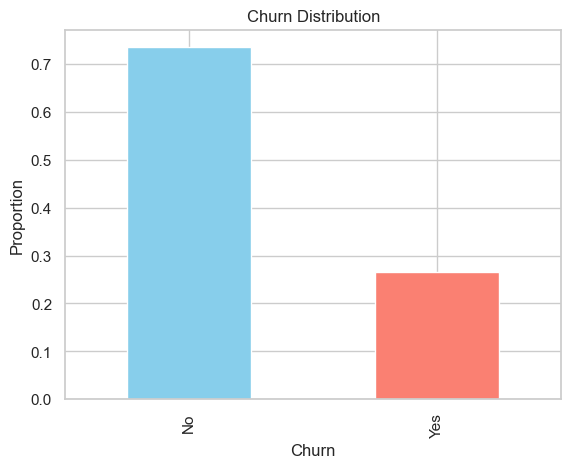

In [34]:
#Target distribution
df['Churn'].value_counts(normalize=True).plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("Churn Distribution")
plt.ylabel("Proportion")
plt.show()


Identify which categories have higher churn

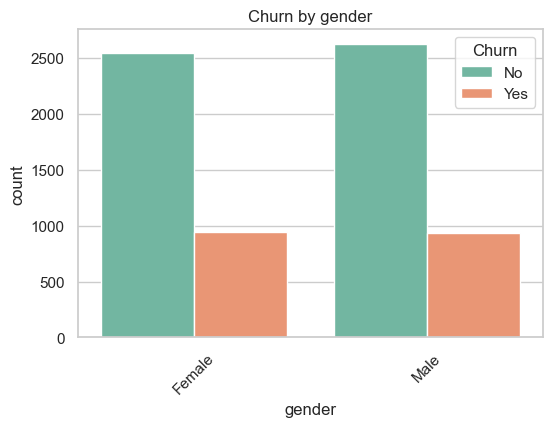

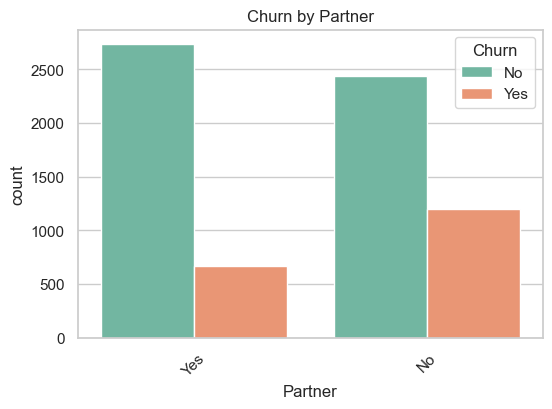

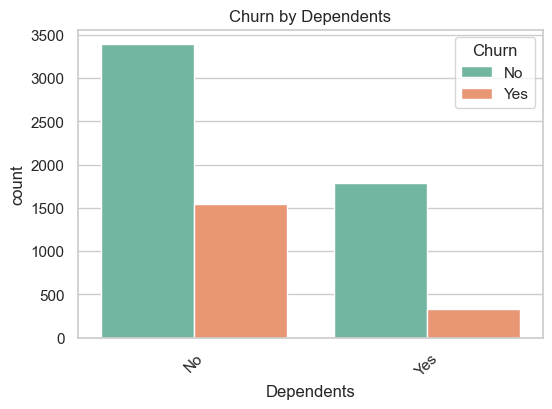

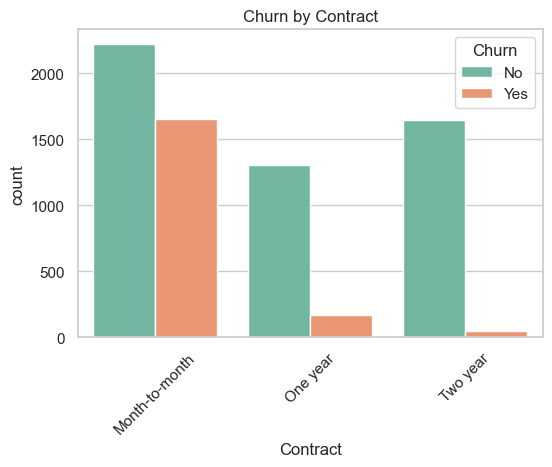

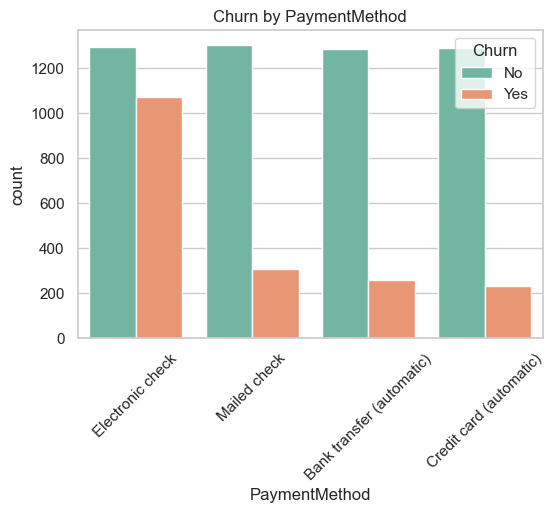

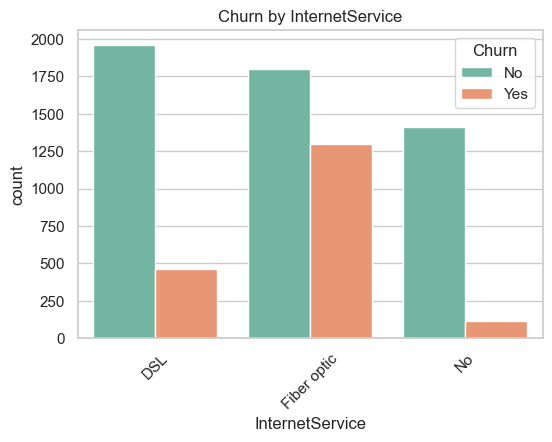

In [35]:
categorical_features = ['gender', 'Partner', 'Dependents', 'Contract', 'PaymentMethod', 'InternetService']

for col in categorical_features:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col, hue='Churn', palette='Set2')
    plt.title(f"Churn by {col}")
    plt.xticks(rotation=45)
    plt.show()


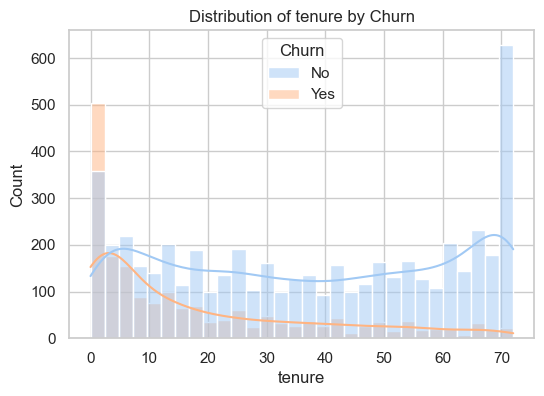

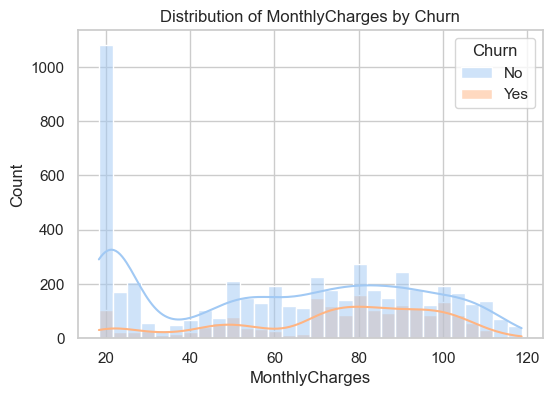

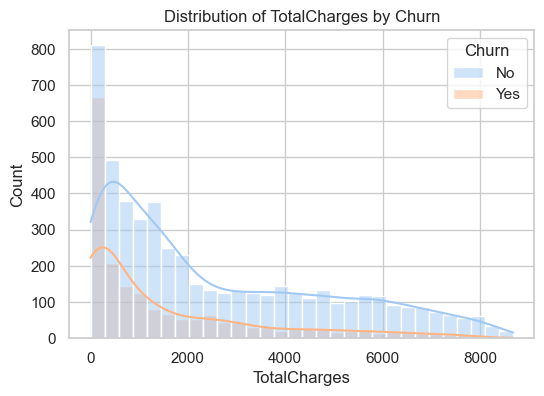

In [36]:
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in numerical_features:
    plt.figure(figsize=(6,4))
    sns.histplot(data=df, x=col, hue='Churn', kde=True, bins=30)
    plt.title(f"Distribution of {col} by Churn")
    plt.show()


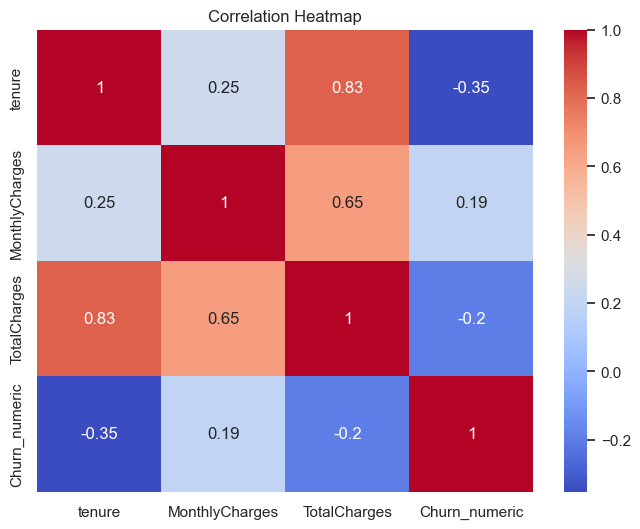

In [37]:
df['Churn_numeric'] = df['Churn'].map({'No': 0, 'Yes': 1})
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


Tenure is negatively correlated with churn, while monthly charges have a mild positive correlation.

In [38]:
from scipy.stats import chi2_contingency

for col in categorical_features:
    table = pd.crosstab(df[col], df['Churn'])
    chi2, p, dof, expected = chi2_contingency(table)
    print(f"{col} → p-value: {p:.4f}")


gender → p-value: 0.4866
Partner → p-value: 0.0000
Dependents → p-value: 0.0000
Contract → p-value: 0.0000
PaymentMethod → p-value: 0.0000
InternetService → p-value: 0.0000


All the features above except for the gender show statistically significant associations with churn (p < 0.05

### Key Insights
- 📉 **Short-tenure** customers (less than 1 year) are most likely to churn.  
- 💸 **High MonthlyCharges** correlate with higher churn, especially for new users.  
- 📃 **Month-to-month contracts** show much higher churn than long-term contracts.  
- 💳 **Electronic check payment** customers churn more than those using credit cards or bank transfers.  
- 👨‍👩‍👧 Customers with **partners or dependents** are less likely to churn.  

These insights will guide feature engineering — e.g., tenure bucketing, encoding contract types, and handling payment method as a categorical predictor.


In [39]:
df.to_csv("../data/processed/cleaned_telco_churn.csv", index=False)

### ✅ Conclusions from EDA
The data shows clear behavioral and demographic patterns associated with churn:
- Customers with short tenure, high monthly bills, and flexible (month-to-month) contracts are most likely to churn.
- Stable, long-term, and bundled-service users tend to stay.

The dataset is clean and ready for feature engineering and model training in the next stage.
